In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from statsmodels.regression.linear_model import OLS
from sklearn.preprocessing import PolynomialFeatures
#import linear_regression
from matplotlib.patches import Rectangle
from functions import *
from matplotlib.patches import Rectangle

## Load in Data

In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
#Keep only Lec, CG, WG, and SQ codes (see paper for discussion of feature selection)
codes_and_CIs = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')

#these will be input features for the model
data = codes_and_CIs[['Lec', 'CG', 'WG', 'SQ',]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

## Feature Selection

We use the Aiken .... 

We need to pick which of the cross terms are relvant to the model

In [3]:
#Establish baseline AIC with all features
n = 1

AIC = 0
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=1,)

    regr = OLS(y_train, X_train).fit()
    AIC += aic_correction(regr.aic, X_train)
true_base_AIC = AIC / 10

In [4]:
#its sets the number of different orders of variables to try
its = 10000

#empty arrays to store which features are retained and associated AICS
AICs = np.zeros(its)
keepers = np.zeros((its, data.shape[1]), dtype=bool)
for j in range(its):
    base_AIC = true_base_AIC * 1

    #randomly shuffle order of variables
    shuffle = np.random.permutation(data.shape[1])
    pruned_data = data[:, shuffle]
    i = 0
    keeping = []
    while i < pruned_data.shape[1]:
        #initialize AIC
        AIC = 0
        #run regression n times with n different subsets of the training data
        for k in range(n):
            
            cut_data = np.delete(pruned_data, i, axis=1)

            delete_set = np.random.randint(0, cut_data.shape[0], 1)
            cut_data = np.delete(cut_data, delete_set, axis=0)
            cut_truth = np.delete(target, delete_set, axis=0)
            
            regr = OLS(cut_truth, cut_data).fit()
            #regr = OLS(truth, cut_data).fit()
            AIC += aic_correction(regr.aic, cut_data)
        #take average AIC over n runs
        av_AIC = AIC / n
        #if AIC improves by removing variable, permanently remove it
        if av_AIC - 1 < base_AIC  :

            pruned_data = np.delete(pruned_data, i, axis=1)
            base_AIC = av_AIC
        #otherwise keep the variable and move to the next one
        else:
            keepers[j, shuffle[i + (data.shape[1] - pruned_data.shape[1])]] = 1

            keeping.append(i + (data.shape[1] - pruned_data.shape[1]))
            i += 1
    AICs[j] = base_AIC
    if not j % 1000:
        print(f'Iteration {j + 1} finished with AIC {base_AIC.round(2)}')

Iteration 1 finished with AIC 92.1
Iteration 1001 finished with AIC 43.33
Iteration 2001 finished with AIC 47.12
Iteration 3001 finished with AIC 43.72
Iteration 4001 finished with AIC 55.07
Iteration 5001 finished with AIC 48.18
Iteration 6001 finished with AIC 44.5
Iteration 7001 finished with AIC 68.17
Iteration 8001 finished with AIC 85.59
Iteration 9001 finished with AIC 41.02


## Model Weight Training and Bootstrap Error on Model Weights

In [43]:
#pick the number of best fits to consider
num_choose = int(10)
good_fits = np.argsort(AICs - np.min(AICs))[:num_choose] 
#set number of iterations
n = 1000
# Empty array to store bootstrap weights for each fit and each data point
bootstrap_weights = np.zeros((len(good_fits), n, data.shape[1]))
for i in range(n):
    #randomly cut 15% of training data
    sample_indices = np.random.permutation(data.shape[0])[:int(.85*data.shape[0])]
    #for each of the selected feature sets, train on remaining 85% and save weights
    for k in range(len(good_fits)):

        boot_data = data[sample_indices][:, keepers[good_fits][k]]
        boot_truth = target[sample_indices]
        regr = OLS(boot_truth, boot_data).fit()
        params = regr.params
        # Store weights for this bootstrap fit
        bootstrap_weights[k, i, keepers[good_fits][k]] = params

#average bootstrap weights across all feature selections        
mean_bootstrap_weights = np.mean(bootstrap_weights.reshape(-1, data.shape[1]), axis=0)
np.save('weights/bootstrap_weights.npy', bootstrap_weights)
np.save('weights/mean_bootstrap_weights.npy', mean_bootstrap_weights)

## Testing on New Data

Mean Absolute Error: 0.14328099187991153


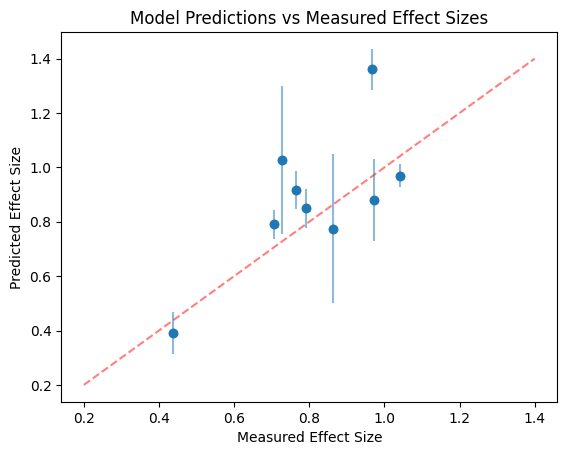

In [44]:
measured_data = pd.read_csv('Measured Data/measured_data.csv')
#Remove classes with pretest means > .6
measured_data = measured_data[measured_data['PreMean'] < .6]


measured_COPUS_data = measured_data[['Lec', 'CG', 'WG', 'SQ']].values
measured_effect_sizes = measured_data['Effect Size'].values

measurement_predictions = add_cross_terms(measured_COPUS_data) @ mean_bootstrap_weights
measurement_bootstrap_errors = np.std(np.mean(bootstrap_weights, axis = 0) @ add_cross_terms(measured_COPUS_data).T, axis=0)

#remove classes with bootstrap error > .4
measurement_predictions = measurement_predictions[measurement_bootstrap_errors < .4]
measured_effect_sizes = measured_effect_sizes[measurement_bootstrap_errors < .4]
measured_COPUS_data = measured_COPUS_data[measurement_bootstrap_errors < .4]
measurement_bootstrap_errors = measurement_bootstrap_errors[measurement_bootstrap_errors < .4]


plt.scatter(measured_effect_sizes, measurement_predictions)
plt.plot([.2, 1.4], [.2, 1.4], 'r--', alpha=0.5)
plt.errorbar(measured_effect_sizes, measurement_predictions, yerr=measurement_bootstrap_errors, fmt='o', alpha=0.5)
plt.xlabel('Measured Effect Size')
plt.ylabel('Predicted Effect Size')
plt.title('Model Predictions vs Measured Effect Sizes')

print('Mean Absolute Error:', np.mean(np.abs(measurement_predictions - measured_effect_sizes)))

## Retrain Model Weights with new data

In [45]:
all_data = np.vstack((data, add_cross_terms(measured_COPUS_data)))
all_target = np.hstack((target, measured_effect_sizes))

print(all_data.shape, all_target.shape)


# Empty array to store bootstrap weights for each fit and each data point
new_bootstrap_weights = np.zeros((len(good_fits), n, data.shape[1]))
for i in range(n):
    #randomly cut 15% of training data
    sample_indices = np.random.permutation(all_data.shape[0])[:int(.85*all_data.shape[0])]
    #for each of the selected feature sets, train on remaining 85% and save weights
    for k in range(len(good_fits)):

        boot_data = all_data[sample_indices][:, keepers[good_fits][k]]
        boot_truth = all_target[sample_indices]
        regr = OLS(boot_truth, boot_data).fit()
        params = regr.params
        # Store weights for this bootstrap fit
        bootstrap_weights[k, i, keepers[good_fits][k]] = params

#average bootstrap weights across all feature selections        
mean_bootstrap_weights = np.mean(bootstrap_weights.reshape(-1, data.shape[1]), axis=0)

(66, 39) (66,)


## Leave-One-Out Testing

We set .4 model prediction error as the threshold over which predictions cannot be considered reliable
We therefore removed all points where the predicted model error is over this threshhold

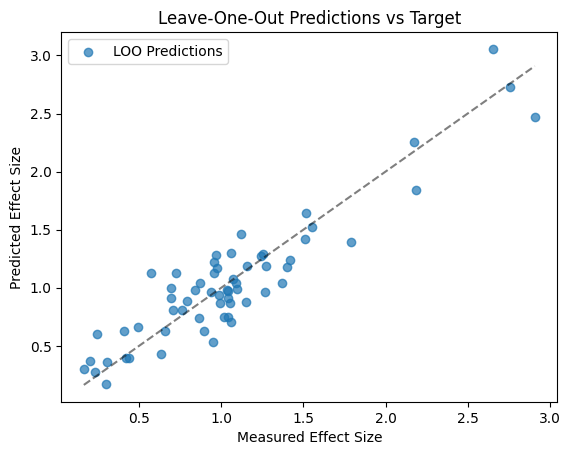

Correlation: 0.921
R^2: 0.848
Mean absolute error: 0.1819


In [58]:
LOO_predictions = np.zeros((len(good_fits), all_data.shape[0]))
# Store LOO weights for each fit and each data point
LOO_weights = np.zeros((len(good_fits), all_data.shape[0], all_data.shape[1]))

#perform leave-one-out cross-validation for each of the best fits
for k in range(len(good_fits)):
    for i in range(all_data.shape[0]):
        cut_data = np.delete(all_data[:, keepers[good_fits][k]], i, axis=0)
        cut_truth = np.delete(all_target, i, axis=0)
        regr = OLS(cut_truth, cut_data).fit()
        params = regr.params
        LOO_predictions[k, i] = all_data[i, keepers[good_fits][k]] @ params
        # Store weights for this LOO fit
        LOO_weights[k, i, keepers[good_fits][k]] = params

#confine predictions to reasonable range
#LOO_predictions = np.clip(LOO_predictions, 0, 3)


LOO_predictions_mean = np.mean(LOO_predictions, axis=0)
LOO_predictions_std = np.std(LOO_predictions, axis=0)

x, y = all_target, LOO_predictions_mean

#remove classes with high prediction error
##############################
x, y = x[LOO_predictions_std < .4], y[LOO_predictions_std < .4]

plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)


m, b = np.polyfit(x, y, 1)
xi = np.linspace(np.min(x), np.max(x), 100)

plt.scatter(x, y, label='LOO Predictions', alpha=0.7)

plt.xlabel(f'Measured Effect Size')
plt.ylabel(f'Predicted Effect Size')
plt.title(f'Leave-One-Out Predictions vs Target')
plt.legend()
plt.show()

print(f'Correlation: {np.corrcoef(x, y)[0, 1]:.3f}')
print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')


## Generate Sample COPUS profiles 

In [59]:
# set the bounds on the parameter space in which to sample
features = 4
maxes = np.max(data[:, :features], axis=0)
mins = np.array([  0, 0, 0, 0,])

#generate a grid of points in the parameter space to test the model on
x_test_pts = []
points_per = 30


for i in range(  len(maxes)):
    x_test_pts.append(np.linspace(mins[i], maxes[i], points_per))


x_grid = np.meshgrid(*x_test_pts)
x_test = np.c_[[grid.ravel() for grid in x_grid]].T


# remove points that are outside of the convex hull of the training data
x_test = x_test[np.where(is_inside_hull(data[:, :4], x_test))]

#add cross terms
x_test = add_cross_terms(x_test)

#find predicted effect size for each point in the grid using the mean bootstrap weights
grid_predictions = x_test @ mean_bootstrap_weights


## Heatmap of Predicted Effect Sizes
For each simulated class profile, we assume that the instructor is spending all time outside of clickers and worksheets on lecture.
Numerically, this is defined as Lec = 1 - WG - .5 * CG

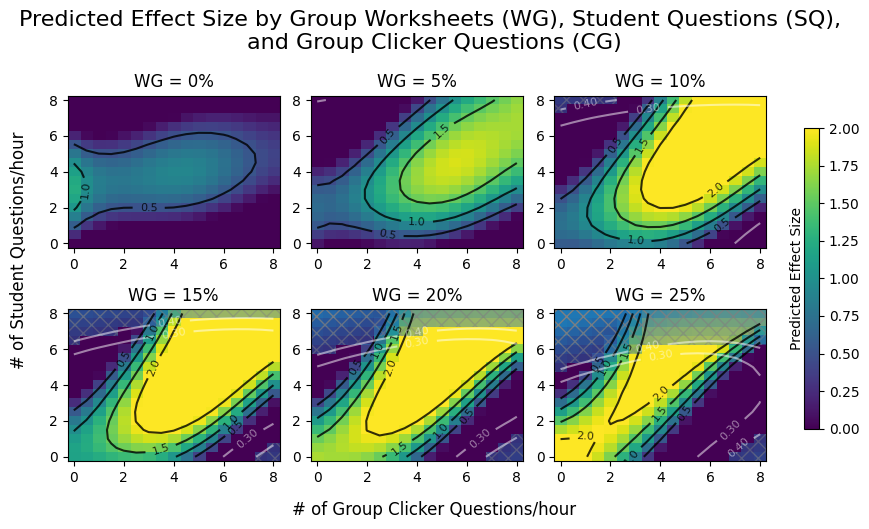

In [80]:

# define paramater arrays for plotting
CG_interval = 1.8 / 30 / 2 #the average clicker question lasts 1.8 intervals
SQ_interval = 1.1 / 30 / 2 #the average student question lasts 1.1 intervals
CGs = np.arange(0, .5, CG_interval)
SQs = np.arange(0, .3 , SQ_interval)
CG_len, SQ_len = len(CGs), len(SQs)
CG_gap, SQ_gap = (CGs[1] - CGs[0])/2, (SQs[1] - SQs[0])/2
WGs = np.round(np.linspace(0, .25, 6), 2)

num_cols = 3
fig, ax = plt.subplots( int(len(WGs)/num_cols), num_cols,  figsize=( 8, int(2.5/num_cols*len(WGs)),))

for i in range(len(WGs)):
    ax_y, ax_x = i%num_cols, i//num_cols
    image = np.zeros((CG_len, SQ_len ))
    stds = np.zeros((CG_len, SQ_len ))

    for l in range(CG_len):
        lec =  np.maximum((1  -  WGs[i] - .5 * CGs[l] ), 0)
        for m in range(SQ_len):
            test_point = np.array([lec, CGs[l], WGs[i], SQs[m]])
            test_point = add_cross_terms(test_point.reshape(1, -1))

            test_grid_predictions = test_point @ mean_bootstrap_weights
            #print(test_grid_predictions, l, m, image[l,m])
            image[l, m] = test_grid_predictions[0]
            stds[l, m] = np.std(np.mean(bootstrap_weights, axis = 0) @ test_point.T)
                
    CG_max = np.minimum(np.max(CGs), np.maximum(0, (1 - WGs[i]) ))
    SQ_max = np.minimum(np.max(SQs), np.maximum(0, (1 - WGs[i]) ))
    image = image.T

    
    c = ax[ax_x, ax_y].imshow(image, origin='lower', aspect='auto', 
                        extent=( 0 , CG_max + CG_interval   , 0 ,  SQ_max + SQ_interval  ,), cmap='viridis', vmin = 0, vmax=2)


    ac = ax[ax_x, ax_y].contour( CGs + CG_gap, SQs + SQ_gap,  image, levels=np.array([ .5, 1, 1.5, 2]), colors='k', alpha=0.8,)
            #labels = [f'{level:.1f}' for level in [.2,  .4, .6, .8, .9]])
    ax[ax_x, ax_y].clabel(ac, inline=True, fontsize=8, fmt='%.1f', colors='k')


# Shade regions where bootstrap error >.2
    rows, cols = np.where(stds.T > 0.4)
    for row, col in zip(rows, cols):
        y = SQs[col]
        x = CGs[row]
        dy = SQ_interval 
        dx = CG_interval 
        rect = Rectangle((x, y), dx, dy, fill=True, hatch='xx', edgecolor='gray', linewidth=0, alpha = np.minimum(4, 4*stds[col, row])/4)
        ax[ax_x, ax_y].add_patch(rect)

    ac = ax[ax_x, ax_y].contour( CGs + CG_gap, SQs + SQ_gap,  stds, levels=np.array([  .3,   .4,  ]), colors='white', alpha=0.5, )
    ax[ax_x, ax_y].clabel(ac, inline=True, fontsize=8, fmt='%.2f', colors='white')

    ax[ax_x, ax_y].set_title(f'WG = {int(100*WGs[i])}%')
    ax[ax_x, ax_y].set_yticks(.11/3 *np.array([0, 2, 4, 6, 8])  +SQ_gap, np.array(['0', '2', '4', '6', '8' ]))
    ax[ax_x, ax_y].set_xticks(np.array([0, .12, .24, .36, .48]) + CG_gap , np.array(['0', '2', '4', '6', '8' ]))

fig.text(0.5, -0.03, '# of Group Clicker Questions/hour', ha='center', fontsize=12)
fig.text(-0.03, 0.5, '# of Student Questions/hour', va='center', rotation='vertical', fontsize=12)
fig.suptitle(f'Predicted Effect Size by Group Worksheets (WG), Student Questions (SQ), \nand Group Clicker Questions (CG)', fontsize=16)

plt.tight_layout()
#colorbar
cbar = fig.colorbar(c, ax=ax.ravel().tolist(), orientation='vertical', fraction=0.02, pad= .05)
cbar.set_label(f'Predicted Effect Size',  rotation=90, labelpad=-50)
cbar.ax.xaxis.set_label_position('top')
    


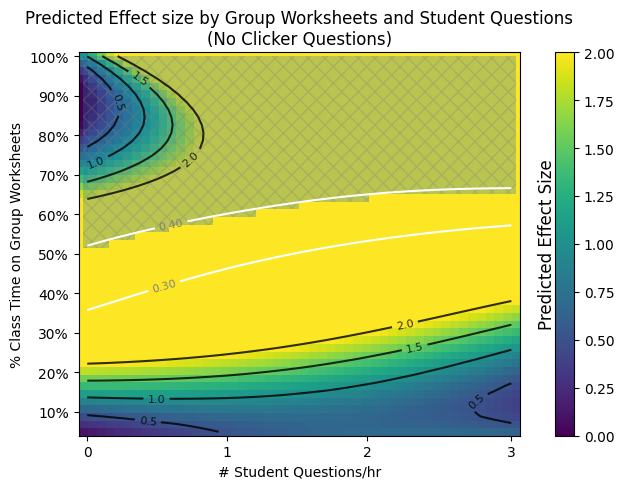

In [83]:
fig, ax = plt.subplots(figsize=(6, 5))

WGs = np.linspace(.05, 1, 50)
SQs = np.linspace(0, .1, 50)
image = np.zeros((len(WGs), len(SQs)))
stds = np.zeros((len(WGs), len(SQs)))
for i in range(len(WGs)):
    for j in range(len(SQs)):
        test_point = np.array([1 - WGs[i], 0, WGs[i], SQs[j]])
        test_point = add_cross_terms(test_point.reshape(1, -1))
        test_grid_predictions = test_point @ mean_bootstrap_weights
        image[i, j] = test_grid_predictions[0]
        stds[i, j] = np.std(np.mean(bootstrap_weights, axis = 0) @ test_point.T)


# Shade regions where bootstrap error >.4
rows, cols = np.where(stds > 0.4)
for row, col in zip(rows, cols):
    x = SQs[col]
    y = WGs[row]
    dx = SQs[1] - SQs[0]  # width of one cell
    dy = WGs[1] - WGs[0]  # height of one cell
    rect = Rectangle((x - dx/2, y - dy), dx, dy, fill=True, alpha = .3, hatch='xx', edgecolor='gray', linewidth=0)
    ax.add_patch(rect)




c = ax.imshow(image, origin='lower', aspect='auto', 
                        extent=(-.002, np.max(SQs) + .002, np.min(WGs)- .01, 1.01), cmap='viridis', vmin = 0, vmax=2)
ac = ax.contour(SQs, WGs, image, levels=np.array([ .5, 1, 1.5, 2]), colors='k', alpha=0.8,)

ax.clabel(ac, inline=True, fontsize=8, fmt='%.1f', colors='k')

d= ax.contour(SQs, WGs, stds, levels=np.array([    .3,  .4, ]), colors='white', alpha=1, )
ax.clabel(d, inline=True, fontsize=8, fmt='%.2f', colors='gray',)
ax.set_xticks(np.array([0, .033, .066, .1]), labels=np.array(['0', '1', '2', '3']))
ax.set_yticks(np.array([.1, .2, .3, .4, .5, .6, .7, .8, .9, 1]), labels=np.array(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']))
plt.xlim(-.002, .102)
ax.set_xlabel('# Student Questions/hr')
ax.set_ylabel('% Class Time on Group Worksheets')
ax.set_title('Predicted Effect size by Group Worksheets and Student Questions\n(No Clicker Questions)')
plt.tight_layout()
#colorbar
cbar = fig.colorbar(c, ax=ax, orientation='vertical', fraction=0.05, pad= .07)
cbar.set_label(f'Predicted Effect Size',  rotation=90, labelpad=-55, fontsize = 12)